# Production Individual Analysis (Option 2)

**Research Question**: How do phonation type and POA affect the acoustic parameters (VOT and F0) that speakers produce?

**Models**:
1. `normed_vot ~ phonation + poa + (1|participant)`
2. `normed_f0 ~ phonation + poa + (1|participant)`

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [2]:
# Load cleaned production data
data_path = Path('output/production_cleaned_data.csv')
df = pd.read_csv(data_path)

print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Data shape: (6934, 22)

Columns: ['filename', 'label', 'rest', 'f0', 'vot', 'rest_duration', 'item', 'prolific_id', 'session_number', 'age', 'gender', 'normed_f0', 'word_duration', 'scaled_vot_by_rest_duration', 'scaled_vot', 'vowel', 'poa', 'normed_word_duration', 'normed_rest_duration', 'normed_age', 'phonation', 'syllable_structure']

First few rows:


,filename,label,rest,f0,vot,rest_duration,item,prolific_id,session_number,age,...,word_duration,scaled_vot_by_rest_duration,scaled_vot,vowel,poa,normed_word_duration,normed_rest_duration,normed_age,phonation,syllable_structure
0,201-1,kk,i#,264.205652,29.886215,223.518167,kki,201,1,28,...,253.404382,0.133708,0.117939,i,dorsal,-0.981279,-0.824416,-1.491829,tense,CV
1,201-1,tt,ak,245.415294,13.525962,208.456056,ttak,201,1,28,...,221.982018,0.064886,0.060933,a,coronal,-1.214036,-0.937666,-1.491829,tense,CVC
2,201-1,k,ok,233.409367,70.244628,152.300629,kok,201,1,28,...,222.545257,0.461223,0.315642,o,dorsal,-1.209864,-1.359893,-1.491829,lenis,CVC
3,201-1,k,i#,216.360169,92.745353,285.581885,ki,201,1,28,...,378.327239,0.324759,0.245146,i,dorsal,-0.055930,-0.357765,-1.491829,lenis,CV
4,201-1,t,ok,224.797479,55.000000,157.544385,tok,201,1,28,...,212.544385,0.349108,0.258769,o,coronal,-1.283944,-1.320466,-1.491829,lenis,CVC


## 2. Data Exploration

In [3]:
# Check for the correct normed VOT column name
vot_cols = [col for col in df.columns if 'vot' in col.lower()]
f0_cols = [col for col in df.columns if 'f0' in col.lower()]

print("VOT-related columns:", vot_cols)
print("F0-related columns:", f0_cols)

# Identify the normalized columns
normed_vot_col = 'scaled_vot' if 'scaled_vot' in df.columns else 'scaled_vot_by_rest_duration'
normed_f0_col = 'normed_f0'

print(f"\nUsing '{normed_vot_col}' for normalized VOT")
print(f"Using '{normed_f0_col}' for normalized F0")

VOT-related columns: ['vot', 'scaled_vot_by_rest_duration', 'scaled_vot']
F0-related columns: ['f0', 'normed_f0']

Using 'scaled_vot' for normalized VOT
Using 'normed_f0' for normalized F0


In [4]:
# Summary statistics
print("=== Phonation types ===")
print(df['phonation'].value_counts())

print("\n=== POA types ===")
print(df['poa'].value_counts())

print("\n=== Number of participants ===")
print(f"Unique participants: {df['prolific_id'].nunique()}")

print("\n=== Descriptive statistics ===")
print(df.groupby('phonation')[[normed_vot_col, normed_f0_col]].describe().round(3))

=== Phonation types ===
phonation
lenis        2475
tense        2316
aspirated    2143
Name: count, dtype: int64

=== POA types ===
poa
dorsal     2316
labial     2310
coronal    2308
Name: count, dtype: int64

=== Number of participants ===
Unique participants: 53

=== Descriptive statistics ===
          scaled_vot                                                   \
               count   mean    std    min    25%    50%    75%    max   
phonation                                                               
aspirated     2143.0  0.232  0.087  0.016  0.170  0.222  0.279  0.630   
lenis         2475.0  0.158  0.076  0.014  0.102  0.145  0.199  0.513   
tense         2316.0  0.053  0.036  0.005  0.029  0.043  0.067  0.378   

          normed_f0                                                   
              count   mean    std    min    25%    50%    75%    max  
phonation                                                             
aspirated    2143.0  0.828  0.703 -4.104  0.466  

In [5]:
# Check for missing values
print("Missing values:")
print(df[[normed_vot_col, normed_f0_col, 'phonation', 'poa', 'prolific_id']].isnull().sum())

# Remove rows with missing values in key columns
df_clean = df.dropna(subset=[normed_vot_col, normed_f0_col, 'phonation', 'poa', 'prolific_id']).copy()
print(f"\nRows after removing missing: {len(df_clean)} (removed {len(df) - len(df_clean)})")

Missing values:
scaled_vot     0
normed_f0      0
phonation      0
poa            0
prolific_id    0
dtype: int64

Rows after removing missing: 6934 (removed 0)


## 3. Visualization

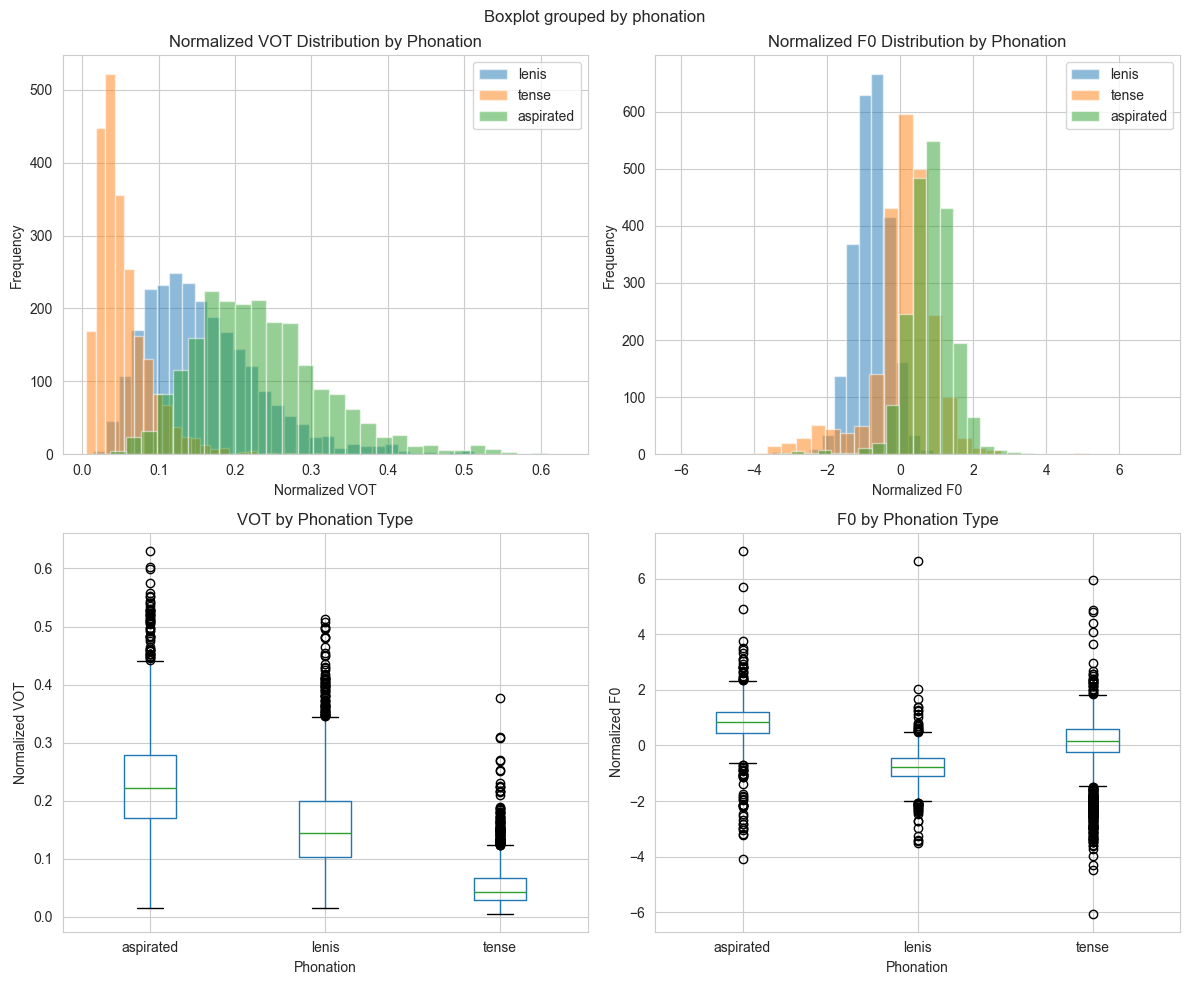

In [6]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# VOT by phonation
phonation_order = ['lenis', 'tense', 'aspirated']
for phon in phonation_order:
    data = df_clean[df_clean['phonation'] == phon][normed_vot_col]
    axes[0, 0].hist(data, alpha=0.5, label=phon, bins=30)
axes[0, 0].set_xlabel('Normalized VOT')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Normalized VOT Distribution by Phonation')
axes[0, 0].legend()

# F0 by phonation
for phon in phonation_order:
    data = df_clean[df_clean['phonation'] == phon][normed_f0_col]
    axes[0, 1].hist(data, alpha=0.5, label=phon, bins=30)
axes[0, 1].set_xlabel('Normalized F0')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Normalized F0 Distribution by Phonation')
axes[0, 1].legend()

# Boxplot VOT
df_clean.boxplot(column=normed_vot_col, by='phonation', ax=axes[1, 0])
axes[1, 0].set_xlabel('Phonation')
axes[1, 0].set_ylabel('Normalized VOT')
axes[1, 0].set_title('VOT by Phonation Type')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# Boxplot F0
df_clean.boxplot(column=normed_f0_col, by='phonation', ax=axes[1, 1])
axes[1, 1].set_xlabel('Phonation')
axes[1, 1].set_ylabel('Normalized F0')
axes[1, 1].set_title('F0 by Phonation Type')
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('output/production_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

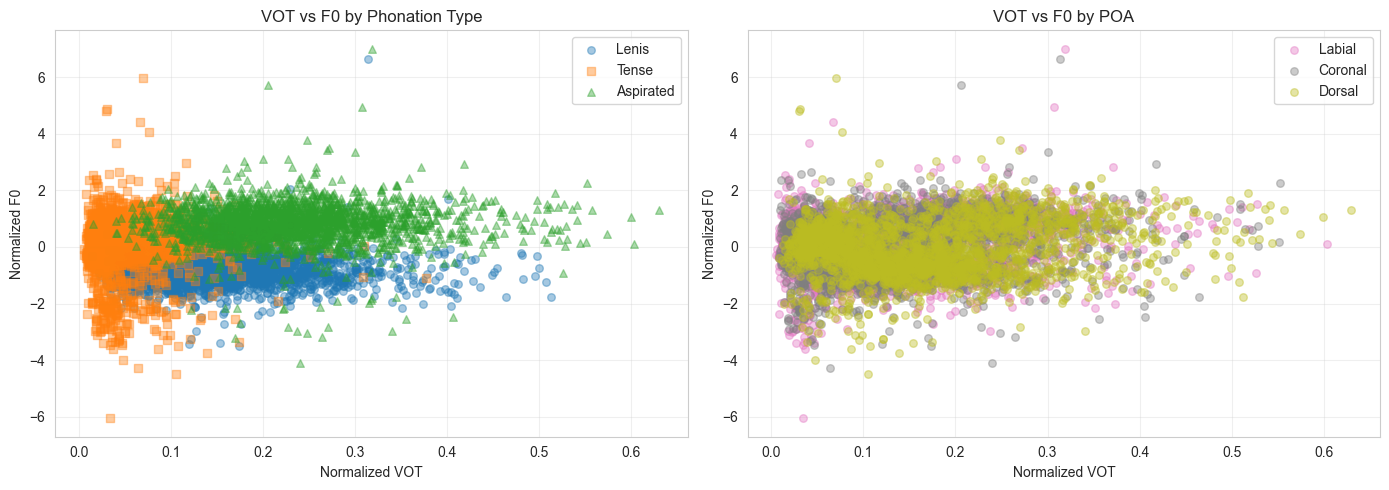

In [7]:
# Scatter plot: VOT vs F0 by phonation and POA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By phonation
colors = {'lenis': '#1f77b4', 'tense': '#ff7f0e', 'aspirated': '#2ca02c'}
markers = {'lenis': 'o', 'tense': 's', 'aspirated': '^'}

for phon in phonation_order:
    data = df_clean[df_clean['phonation'] == phon]
    axes[0].scatter(data[normed_vot_col], data[normed_f0_col], 
                   c=colors[phon], marker=markers[phon], 
                   alpha=0.4, s=30, label=phon.capitalize())

axes[0].set_xlabel('Normalized VOT')
axes[0].set_ylabel('Normalized F0')
axes[0].set_title('VOT vs F0 by Phonation Type')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# By POA
poa_colors = {'labial': '#e377c2', 'coronal': '#7f7f7f', 'dorsal': '#bcbd22'}
for poa in ['labial', 'coronal', 'dorsal']:
    data = df_clean[df_clean['poa'] == poa]
    axes[1].scatter(data[normed_vot_col], data[normed_f0_col], 
                   c=poa_colors[poa], alpha=0.4, s=30, label=poa.capitalize())

axes[1].set_xlabel('Normalized VOT')
axes[1].set_ylabel('Normalized F0')
axes[1].set_title('VOT vs F0 by POA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/production_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Individual Participant Models

We'll fit separate OLS models for each participant:
- **Model per participant**: normed_vot ~ phonation + poa
- **Model per participant**: normed_f0 ~ phonation + poa
- This allows us to examine individual differences in production patterns

In [9]:
# Install/import required packages
try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    print("statsmodels is already installed")
except ImportError:
    print("Installing statsmodels...")
    !pip install statsmodels
    import statsmodels.api as sm
    from statsmodels.formula.api import ols

statsmodels is already installed


### Prepare Data for Modeling

In [10]:
# Prepare data with proper column names
df_model = df_clean.copy()
df_model = df_model.rename(columns={normed_vot_col: 'normed_vot', normed_f0_col: 'normed_f0'})

# Set reference levels (lenis for phonation, labial for poa)
df_model['phonation'] = pd.Categorical(df_model['phonation'], 
                                       categories=['lenis', 'tense', 'aspirated'], 
                                       ordered=False)
df_model['poa'] = pd.Categorical(df_model['poa'], 
                                 categories=['labial', 'coronal', 'dorsal'], 
                                 ordered=False)

participants = df_model['prolific_id'].unique()
print(f"Total data points: {len(df_model)}")
print(f"Number of participants: {len(participants)}")
print(f"\nData points per participant:")
print(df_model['prolific_id'].value_counts().describe())

Total data points: 6934
Number of participants: 53

Data points per participant:
count     53.000000
mean     130.830189
std       13.129145
min       45.000000
25%      132.000000
50%      134.000000
75%      135.000000
max      135.000000
Name: count, dtype: float64


### Fit Individual Models: VOT

In [11]:
# Fit VOT model for each participant
print("=" * 70)
print("Fitting VOT models for each participant...")
print("=" * 70)

vot_coefficients = []
vot_model_stats = []

for participant in participants:
    # Get participant data
    p_data = df_model[df_model['prolific_id'] == participant].copy()
    
    # Check if participant has enough data and variability
    if len(p_data) < 10:
        print(f"Skipping {participant}: insufficient data (n={len(p_data)})")
        continue
    
    # Check for variability in predictors
    if p_data['phonation'].nunique() < 2 or p_data['poa'].nunique() < 2:
        print(f"Skipping {participant}: insufficient variability in predictors")
        continue
    
    try:
        # Fit model
        model = ols('normed_vot ~ phonation + poa', data=p_data).fit()
        
        # Store coefficients
        coef_dict = {'participant': participant}
        coef_dict.update(model.params.to_dict())
        vot_coefficients.append(coef_dict)
        
        # Store model statistics
        vot_model_stats.append({
            'participant': participant,
            'n_obs': len(p_data),
            'r_squared': model.rsquared,
            'adj_r_squared': model.rsquared_adj,
            'f_statistic': model.fvalue,
            'f_pvalue': model.f_pvalue
        })
        
    except Exception as e:
        print(f"Error fitting model for {participant}: {e}")
        continue

vot_coef_df = pd.DataFrame(vot_coefficients)
vot_stats_df = pd.DataFrame(vot_model_stats)

print(f"\nSuccessfully fit models for {len(vot_coef_df)} participants")
print(f"\nCoefficient columns: {vot_coef_df.columns.tolist()}")

Fitting VOT models for each participant...

Successfully fit models for 53 participants

Coefficient columns: ['participant', 'Intercept', 'phonation[T.tense]', 'phonation[T.aspirated]', 'poa[T.coronal]', 'poa[T.dorsal]']


In [12]:
# Display VOT results summary
print("\n=== VOT Model Coefficients Summary ===")
print("\nMean coefficients across participants:")
print(vot_coef_df.drop('participant', axis=1).mean().round(4))

print("\nStandard deviation of coefficients:")
print(vot_coef_df.drop('participant', axis=1).std().round(4))

print("\n=== VOT Model Statistics Summary ===")
print(vot_stats_df.describe().round(3))


=== VOT Model Coefficients Summary ===

Mean coefficients across participants:
Intercept                 0.1430
phonation[T.tense]       -0.1026
phonation[T.aspirated]    0.0765
poa[T.coronal]           -0.0028
poa[T.dorsal]             0.0402
dtype: float64

Standard deviation of coefficients:
Intercept                 0.0466
phonation[T.tense]        0.0383
phonation[T.aspirated]    0.0283
poa[T.coronal]            0.0093
poa[T.dorsal]             0.0157
dtype: float64

=== VOT Model Statistics Summary ===
       participant    n_obs  r_squared  adj_r_squared  f_statistic  f_pvalue
count       53.000   53.000     53.000         53.000       53.000      53.0
mean       468.981  130.830      0.715          0.705       86.549       0.0
std        146.248   13.129      0.073          0.075       33.740       0.0
min        201.000   45.000      0.543          0.529       24.815       0.0
25%        314.000  132.000      0.658          0.647       61.199       0.0
50%        505.000  134

### Fit Individual Models: F0

In [13]:
# Fit F0 model for each participant
print("=" * 70)
print("Fitting F0 models for each participant...")
print("=" * 70)

f0_coefficients = []
f0_model_stats = []

for participant in participants:
    # Get participant data
    p_data = df_model[df_model['prolific_id'] == participant].copy()
    
    # Check if participant has enough data and variability
    if len(p_data) < 10:
        continue
    
    if p_data['phonation'].nunique() < 2 or p_data['poa'].nunique() < 2:
        continue
    
    try:
        # Fit model
        model = ols('normed_f0 ~ phonation + poa', data=p_data).fit()
        
        # Store coefficients
        coef_dict = {'participant': participant}
        coef_dict.update(model.params.to_dict())
        f0_coefficients.append(coef_dict)
        
        # Store model statistics
        f0_model_stats.append({
            'participant': participant,
            'n_obs': len(p_data),
            'r_squared': model.rsquared,
            'adj_r_squared': model.rsquared_adj,
            'f_statistic': model.fvalue,
            'f_pvalue': model.f_pvalue
        })
        
    except Exception as e:
        print(f"Error fitting model for {participant}: {e}")
        continue

f0_coef_df = pd.DataFrame(f0_coefficients)
f0_stats_df = pd.DataFrame(f0_model_stats)

print(f"\nSuccessfully fit models for {len(f0_coef_df)} participants")
print(f"\nCoefficient columns: {f0_coef_df.columns.tolist()}")

Fitting F0 models for each participant...

Successfully fit models for 53 participants

Coefficient columns: ['participant', 'Intercept', 'phonation[T.tense]', 'phonation[T.aspirated]', 'poa[T.coronal]', 'poa[T.dorsal]']


In [14]:
# Display F0 results summary
print("\n=== F0 Model Coefficients Summary ===")
print("\nMean coefficients across participants:")
print(f0_coef_df.drop('participant', axis=1).mean().round(4))

print("\nStandard deviation of coefficients:")
print(f0_coef_df.drop('participant', axis=1).std().round(4))

print("\n=== F0 Model Statistics Summary ===")
print(f0_stats_df.describe().round(3))


=== F0 Model Coefficients Summary ===

Mean coefficients across participants:
Intercept                -0.7923
phonation[T.tense]        0.8396
phonation[T.aspirated]    1.6053
poa[T.coronal]           -0.0071
poa[T.dorsal]             0.0558
dtype: float64

Standard deviation of coefficients:
Intercept                 0.3276
phonation[T.tense]        0.5582
phonation[T.aspirated]    0.4375
poa[T.coronal]            0.1705
poa[T.dorsal]             0.1723
dtype: float64

=== F0 Model Statistics Summary ===
       participant    n_obs  r_squared  adj_r_squared  f_statistic  f_pvalue
count       53.000   53.000     53.000         53.000       53.000    53.000
mean       468.981  130.830      0.517          0.501       53.049     0.001
std        146.248   13.129      0.217          0.225       52.054     0.009
min        201.000   45.000      0.065          0.037        2.272     0.000
25%        314.000  132.000      0.351          0.320       16.435     0.000
50%        505.000  134.0

## 5. Visualize Individual Coefficients

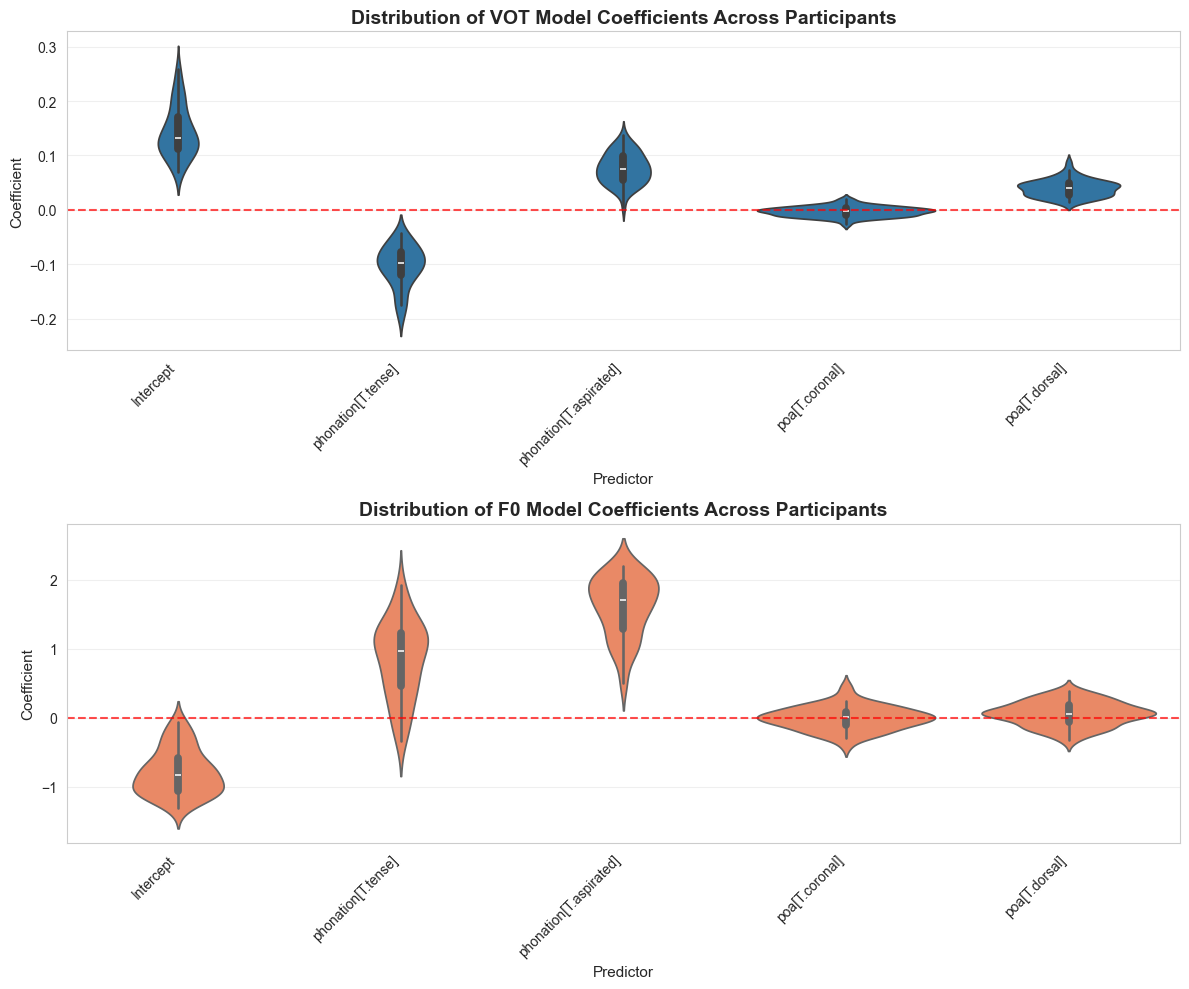

Note: Each violin shows the distribution of coefficients from 53 individual participant models
Reference levels: lenis (phonation), labial (POA)


In [15]:
# Prepare data for plotting (melt to long format)
vot_coef_long = vot_coef_df.drop('participant', axis=1).melt(var_name='Predictor', value_name='Coefficient')
f0_coef_long = f0_coef_df.drop('participant', axis=1).melt(var_name='Predictor', value_name='Coefficient')

# Create violin plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# VOT coefficients distribution
sns.violinplot(data=vot_coef_long, x='Predictor', y='Coefficient', ax=axes[0], inner='box')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].set_title('Distribution of VOT Model Coefficients Across Participants', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predictor', fontsize=11)
axes[0].set_ylabel('Coefficient', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# F0 coefficients distribution
sns.violinplot(data=f0_coef_long, x='Predictor', y='Coefficient', ax=axes[1], inner='box', color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].set_title('Distribution of F0 Model Coefficients Across Participants', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predictor', fontsize=11)
axes[1].set_ylabel('Coefficient', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('output/individual_coefficients_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Note: Each violin shows the distribution of coefficients from {len(vot_coef_df)} individual participant models")
print("Reference levels: lenis (phonation), labial (POA)")

## 6. Additional Visualizations

## 7. Summary and Interpretation

In [ ]:
print("=" * 80)
print("INDIVIDUAL PARTICIPANT ANALYSIS SUMMARY")
print("=" * 80)

print(f"\nNumber of participants with valid models: {len(vot_coef_df)}")
print(f"Reference levels: Lenis (phonation), Labial (POA)")

print("\n" + "=" * 80)
print("VOT PRODUCTION: Average Effects Across Participants")
print("=" * 80)

for col in vot_coef_df.columns:
    if col != 'participant':
        mean_coef = vot_coef_df[col].mean()
        std_coef = vot_coef_df[col].std()
        # One-sample t-test against 0
        from scipy import stats
        t_stat, p_val = stats.ttest_1samp(vot_coef_df[col].dropna(), 0)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f"\n{col}:")
        print(f"  Mean = {mean_coef:.4f} ± {std_coef:.4f} (SD)")
        print(f"  t({len(vot_coef_df)-1}) = {t_stat:.3f}, p = {p_val:.4f} {sig}")

print("\n" + "=" * 80)
print("F0 PRODUCTION: Average Effects Across Participants")
print("=" * 80)

for col in f0_coef_df.columns:
    if col != 'participant':
        mean_coef = f0_coef_df[col].mean()
        std_coef = f0_coef_df[col].std()
        t_stat, p_val = stats.ttest_1samp(f0_coef_df[col].dropna(), 0)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f"\n{col}:")
        print(f"  Mean = {mean_coef:.4f} ± {std_coef:.4f} (SD)")
        print(f"  t({len(f0_coef_df)-1}) = {t_stat:.3f}, p = {p_val:.4f} {sig}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("  - Each coefficient represents the average effect across all participants")
print("  - Positive = higher values relative to reference level")
print("  - Negative = lower values relative to reference level")
print("  - Significance tests whether the average effect differs from zero")
print("  - *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("=" * 80)

In [ ]:
# Box plots for key effects
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VOT: Phonation effects
if 'phonation[T.tense]' in vot_coef_df.columns and 'phonation[T.aspirated]' in vot_coef_df.columns:
    phonation_data = vot_coef_df[['phonation[T.tense]', 'phonation[T.aspirated]']].melt(
        var_name='Contrast', value_name='Coefficient'
    )
    sns.boxplot(data=phonation_data, x='Contrast', y='Coefficient', ax=axes[0, 0])
    axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 0].set_title('VOT: Phonation Effects (vs. Lenis)', fontweight='bold')
    axes[0, 0].set_xticklabels(['Tense', 'Aspirated'])
    axes[0, 0].grid(True, alpha=0.3, axis='y')

# VOT: POA effects
if 'poa[T.coronal]' in vot_coef_df.columns and 'poa[T.dorsal]' in vot_coef_df.columns:
    poa_data = vot_coef_df[['poa[T.coronal]', 'poa[T.dorsal]']].melt(
        var_name='Contrast', value_name='Coefficient'
    )
    sns.boxplot(data=poa_data, x='Contrast', y='Coefficient', ax=axes[0, 1])
    axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 1].set_title('VOT: POA Effects (vs. Labial)', fontweight='bold')
    axes[0, 1].set_xticklabels(['Coronal', 'Dorsal'])
    axes[0, 1].grid(True, alpha=0.3, axis='y')

# F0: Phonation effects
if 'phonation[T.tense]' in f0_coef_df.columns and 'phonation[T.aspirated]' in f0_coef_df.columns:
    phonation_data = f0_coef_df[['phonation[T.tense]', 'phonation[T.aspirated]']].melt(
        var_name='Contrast', value_name='Coefficient'
    )
    sns.boxplot(data=phonation_data, x='Contrast', y='Coefficient', ax=axes[1, 0], color='coral')
    axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 0].set_title('F0: Phonation Effects (vs. Lenis)', fontweight='bold')
    axes[1, 0].set_xticklabels(['Tense', 'Aspirated'])
    axes[1, 0].grid(True, alpha=0.3, axis='y')

# F0: POA effects
if 'poa[T.coronal]' in f0_coef_df.columns and 'poa[T.dorsal]' in f0_coef_df.columns:
    poa_data = f0_coef_df[['poa[T.coronal]', 'poa[T.dorsal]']].melt(
        var_name='Contrast', value_name='Coefficient'
    )
    sns.boxplot(data=poa_data, x='Contrast', y='Coefficient', ax=axes[1, 1], color='coral')
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].set_title('F0: POA Effects (vs. Labial)', fontweight='bold')
    axes[1, 1].set_xticklabels(['Coronal', 'Dorsal'])
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/coefficient_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Export Results

In [ ]:
# Save individual participant coefficients
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

vot_coef_df.to_csv(output_dir / 'individual_vot_coefficients.csv', index=False)
f0_coef_df.to_csv(output_dir / 'individual_f0_coefficients.csv', index=False)

# Save model statistics
vot_stats_df.to_csv(output_dir / 'individual_vot_model_stats.csv', index=False)
f0_stats_df.to_csv(output_dir / 'individual_f0_model_stats.csv', index=False)

# Save summary statistics
summary_stats = {
    'VOT_coefficients': vot_coef_df.drop('participant', axis=1).describe(),
    'F0_coefficients': f0_coef_df.drop('participant', axis=1).describe()
}

with pd.ExcelWriter(output_dir / 'coefficient_summary_statistics.xlsx') as writer:
    summary_stats['VOT_coefficients'].to_excel(writer, sheet_name='VOT')
    summary_stats['F0_coefficients'].to_excel(writer, sheet_name='F0')

print("Results saved to output/ directory:")
print("  - individual_vot_coefficients.csv (all participant coefficients)")
print("  - individual_f0_coefficients.csv (all participant coefficients)")
print("  - individual_vot_model_stats.csv (R², F-statistics, etc.)")
print("  - individual_f0_model_stats.csv (R², F-statistics, etc.)")
print("  - coefficient_summary_statistics.xlsx (descriptive stats)")
print(f"\nTotal participants analyzed: {len(vot_coef_df)}")